# Restaurant Data Analysis

**Dataset:** 9,551 restaurants from 15 countries (21 columns)
**Tools:** Python, Pandas, Matplotlib, Seaborn

Simple steps in this notebook:
1. Load and clean the data
2. Level 1 - Basic analysis
3. Level 2 - Intermediate analysis
4. Level 3 - Advanced analysis (reviews are not possible, see below)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Load Data

In [2]:
df = pd.read_csv("../data/restaurants.csv", encoding="utf-8-sig")
print(df.shape)
df.head()

(9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenue, Poblacion, Makati City","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

## 2. Data Cleaning

What we check and do:
- **Missing values** - only `Cuisines` has missing values (9). We fill them with "Unknown".
- **Duplicates** - check if any row is repeated.
- **Unrated restaurants** - rating = 0 means "not rated yet", not a bad rating. We keep them for counts, but **remove them when we calculate average ratings**.

In [4]:
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Duplicate rows:", df.duplicated().sum())

Cuisines    9
dtype: int64
Duplicate rows: 0


In [5]:
# fill missing cuisines
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

# rated = only restaurants that have a rating (rating above 0)
rated = df[df["Aggregate rating"] > 0]

print("All restaurants  :", len(df))
print("Rated restaurants:", len(rated))
print("Not rated        :", len(df) - len(rated))

All restaurants  : 9551
Rated restaurants: 7403
Not rated        : 2148


In [6]:
# save the clean file (used for SQL and Power BI)
clean = df.copy()
clean.columns = clean.columns.str.lower().str.replace(" ", "_")
clean.to_csv("../data/restaurants_clean.csv", index=False)

---
# Level 1 - Basic Analysis
## Task 1: Top Cuisines

**Logic:** One restaurant can have many cuisines like "North Indian, Chinese". We split them into separate rows, count each cuisine, then find the percentage.

In [7]:
cuisines = df["Cuisines"].str.split(", ").explode()   # one cuisine per row
top3 = cuisines.value_counts().head(3)

cuisine_tbl = pd.DataFrame({"Restaurants": top3,
                            "Percentage": (top3 / len(df) * 100).round(2)})
cuisine_tbl

,Restaurants,Percentage
Cuisines,,
North Indian,3960,41.46
Chinese,2735,28.64
Fast Food,1986,20.79


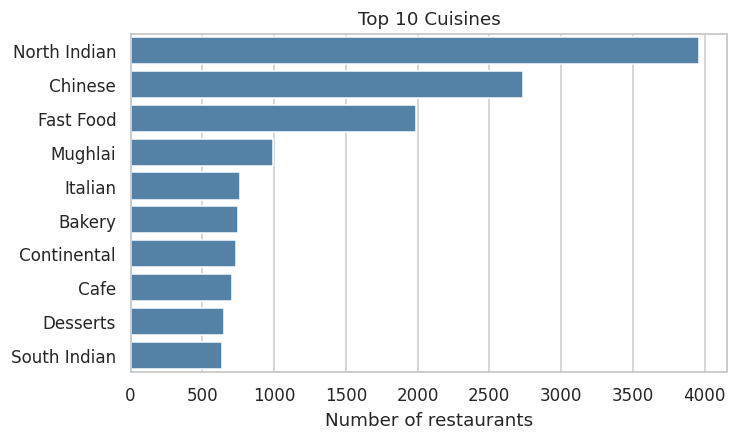

In [8]:
plt.figure(figsize=(7, 4))
sns.barplot(x=cuisines.value_counts().head(10).values, y=cuisines.value_counts().head(10).index, color="steelblue")
plt.title("Top 10 Cuisines")
plt.xlabel("Number of restaurants")
plt.ylabel("")
plt.savefig("../images/01_top_cuisines.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** The top 3 cuisines are **North Indian** (41.46%), **Chinese** (28.64%) and **Fast Food** (20.79%). The total is more than 100% because one restaurant can serve more than one cuisine.

## Task 2: City Analysis

In [9]:
# 1. city with the most restaurants
city_count = df["City"].value_counts()
print("City with most restaurants:", city_count.index[0], "-", city_count.iloc[0])

# 2. average rating of each city (rated restaurants only)
city_rating = rated.groupby("City")["Aggregate rating"].mean().round(2)

# 3. highest average rating
print("Highest average rating:", city_rating.idxmax(), "-", city_rating.max())
print("Rated restaurants in that city:", (rated["City"] == city_rating.idxmax()).sum())

City with most restaurants: New Delhi - 5473
Highest average rating: Inner City - 4.9
Rated restaurants in that city: 2


The city with the highest average has very few restaurants, so it is not a fair result. Let us only look at cities with **20 or more rated restaurants**.

In [10]:
city_info = rated.groupby("City")["Aggregate rating"].agg(["count", "mean"]).round(2)
big_cities = city_info[city_info["count"] >= 20].sort_values("mean", ascending=False)
big_cities.head(5)

,count,mean
City,,
London,20,4.54
Orlando,20,4.47
Rest of Hawaii,20,4.41
Tampa Bay,20,4.41
Bangalore,20,4.38


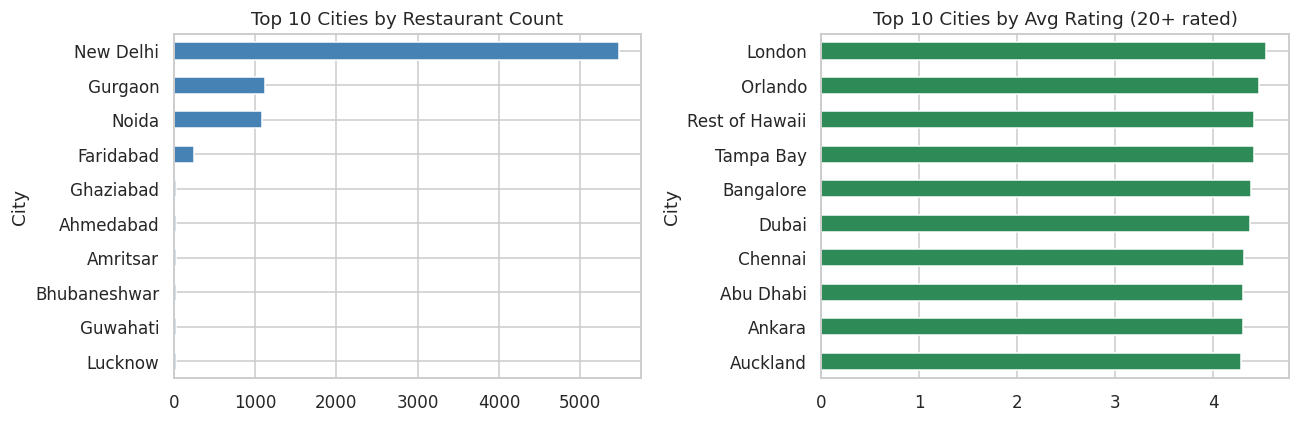

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

city_count.head(10).plot(kind="barh", ax=ax[0], color="steelblue")
ax[0].set_title("Top 10 Cities by Restaurant Count")
ax[0].invert_yaxis()

big_cities["mean"].head(10).plot(kind="barh", ax=ax[1], color="seagreen")
ax[1].set_title("Top 10 Cities by Avg Rating (20+ rated)")
ax[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../images/02_city_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** **New Delhi** has the most restaurants (5,473). Among cities with 20+ rated restaurants, **London** has the best average rating (4.54).

## Task 3: Price Range Distribution

In [12]:
price = df["Price range"].value_counts().sort_index()
price_pct = (price / len(df) * 100).round(2)

pd.DataFrame({"Restaurants": price, "Percentage": price_pct})

,Restaurants,Percentage
Price range,,
1,4444,46.53
2,3113,32.59
3,1408,14.74
4,586,6.14


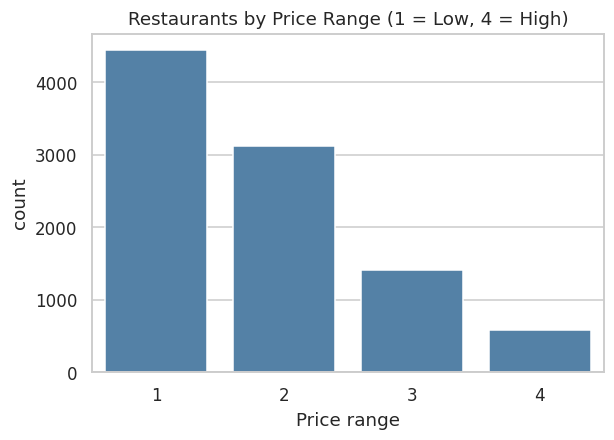

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Price range", data=df, color="steelblue")
plt.title("Restaurants by Price Range (1 = Low, 4 = High)")
plt.savefig("../images/03_price_range.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** Most restaurants are low priced. Price range 1 has **46.53%** and price range 2 has **32.59%**. Only **6.14%** are in price range 4.

## Task 4: Online Delivery

In [14]:
# % of restaurants with online delivery
delivery_pct = (df["Has Online delivery"].value_counts(normalize=True) * 100).round(2)
print(delivery_pct)

# average rating with and without delivery (rated only)
avg = rated.groupby("Has Online delivery")["Aggregate rating"].mean().round(2)
print()
print(avg)

Has Online delivery
No     74.34
Yes    25.66
Name: proportion, dtype: float64

Has Online delivery
No     3.47
Yes    3.38
Name: Aggregate rating, dtype: float64


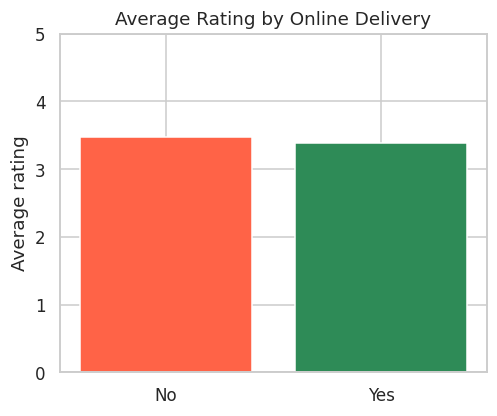

In [15]:
plt.figure(figsize=(5, 4))
plt.bar(avg.index, avg.values, color=["tomato", "seagreen"])
plt.title("Average Rating by Online Delivery")
plt.ylabel("Average rating")
plt.ylim(0, 5)
plt.savefig("../images/04_online_delivery.png", dpi=120, bbox_inches="tight")
plt.show()

**Extra check:** Almost all delivery restaurants are in India (country code 1). Let us compare inside India only to be fair.

In [16]:
india = rated[rated["Country Code"] == 1]
india_avg = india.groupby("Has Online delivery")["Aggregate rating"].mean().round(2)
india_avg

,Aggregate rating
Has Online delivery,
No,3.34
Yes,3.37


**Insight:** 25.66% of restaurants offer online delivery. Overall, restaurants with delivery have a slightly lower rating (3.38 vs 3.47). But inside India the two groups are almost the same (3.37 vs 3.34). So online delivery does **not** change the rating much.

---
# Level 2 - Intermediate Analysis
## Task 1: Restaurant Ratings

In [17]:
print(rated["Aggregate rating"].describe().round(2))

# group ratings into ranges
bins = [0, 2, 2.5, 3, 3.5, 4, 4.5, 5]
rating_range = pd.cut(rated["Aggregate rating"], bins=bins)
range_count = rating_range.value_counts().sort_index()
print()
print(range_count)
print("Most common range:", range_count.idxmax())

print()
print("Average votes (all restaurants)  :", round(df["Votes"].mean(), 1))
print("Average votes (rated restaurants):", round(rated["Votes"].mean(), 1))

count    7403.00
mean        3.44
std         0.55
min         1.80
25%         3.00
50%         3.40
75%         3.80
max         4.90
Name: Aggregate rating, dtype: float64

Aggregate rating
(0.0, 2.0]      10
(2.0, 2.5]     286
(2.5, 3.0]    1605
(3.0, 3.5]    2502
(3.5, 4.0]    1886
(4.0, 4.5]     908
(4.5, 5.0]     206
Name: count, dtype: int64
Most common range: (3.0, 3.5]

Average votes (all restaurants)  : 156.9
Average votes (rated restaurants): 202.2


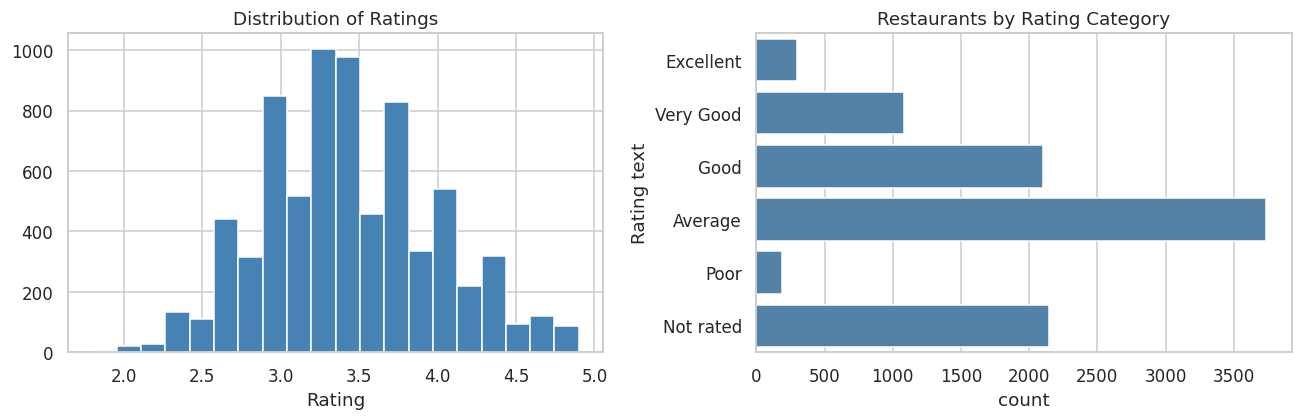

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(rated["Aggregate rating"], bins=20, color="steelblue", edgecolor="white")
ax[0].set_title("Distribution of Ratings")
ax[0].set_xlabel("Rating")

order = ["Excellent", "Very Good", "Good", "Average", "Poor", "Not rated"]
sns.countplot(y="Rating text", data=df, order=order, color="steelblue", ax=ax[1])
ax[1].set_title("Restaurants by Rating Category")

plt.tight_layout()
plt.savefig("../images/05_ratings.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** The most common rating range is **(3.0, 3.5]**. The average rating is 3.44. The average number of votes is about 202.

## Task 2: Cuisine Combination

**Logic:** The `Cuisines` column already has the full combination (for example "Chinese, North Indian"). We count how many times each combination appears. (To keep it simple, the same cuisines in a different order are counted as different combinations.)

In [19]:
# only combinations with 2 or more cuisines
combo = df[df["Cuisines"].str.contains(",")]

top_combo = combo["Cuisines"].value_counts().head(10)
top_combo

,count
Cuisines,
"North Indian, Chinese",511
"North Indian, Mughlai",334
"North Indian, Mughlai, Chinese",197
"Bakery, Desserts",170
"Pizza, Fast Food",131
"Chinese, Fast Food",118
"Mithai, Street Food",116
"Bakery, Fast Food",108
"Chinese, North Indian",105


In [20]:
# average rating of each combination (rated only, at least 20 restaurants)
combo_rated = rated[rated["Cuisines"].str.contains(",")]
combo_info = combo_rated.groupby("Cuisines")["Aggregate rating"].agg(["count", "mean"]).round(2)
combo_info = combo_info[combo_info["count"] >= 20].sort_values("mean", ascending=False)

print("Highest rated combinations:")
print(combo_info.head(5))
print()
print("Lowest rated combinations:")
print(combo_info.tail(5))

Highest rated combinations:
                           count  mean
Cuisines                              
Italian, Pizza                23  3.80
Desserts, Ice Cream           24  3.57
Chinese, Thai                 48  3.52
North Indian, Continental     26  3.52
Burger, Fast Food             39  3.49

Lowest rated combinations:
                                          count  mean
Cuisines                                             
Italian, Pizza, Fast Food                    34  3.04
North Indian, Chinese, Fast Food             61  3.03
Chinese, Fast Food                           80  3.03
American, Fast Food, Salad, Healthy Food     60  3.00
Raw Meats, Fast Food                         27  2.99


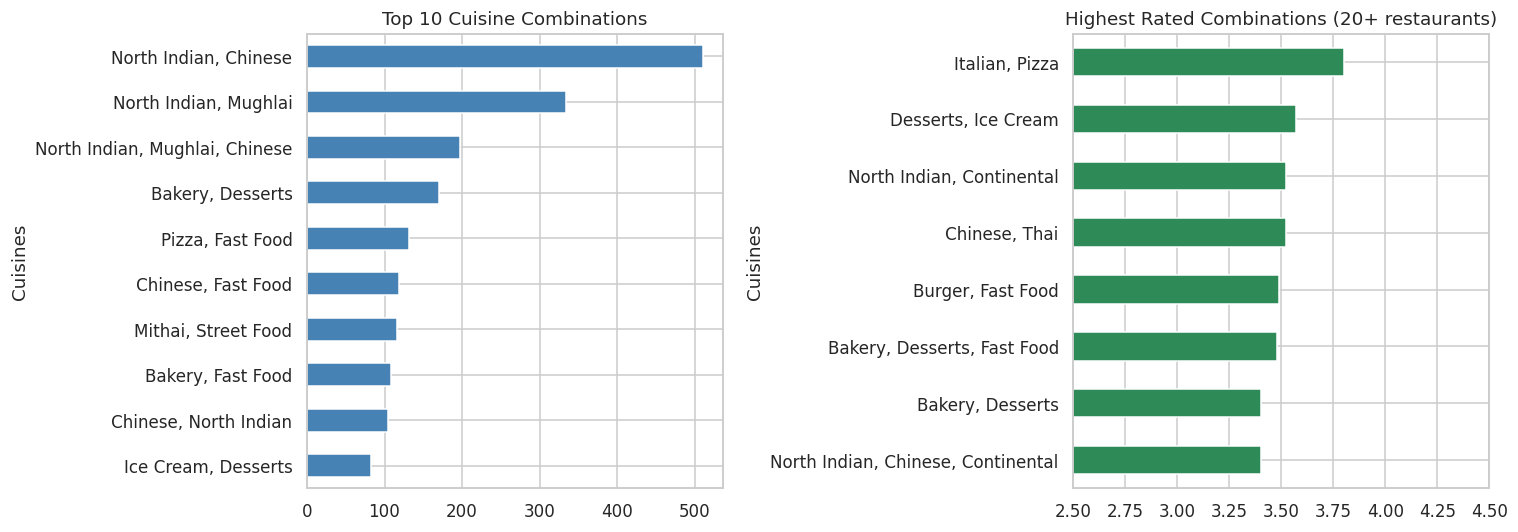

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

top_combo.sort_values().plot(kind="barh", ax=ax[0], color="steelblue")
ax[0].set_title("Top 10 Cuisine Combinations")

combo_info["mean"].head(8).sort_values().plot(kind="barh", ax=ax[1], color="seagreen")
ax[1].set_title("Highest Rated Combinations (20+ restaurants)")
ax[1].set_xlim(2.5, 4.5)

plt.tight_layout()
plt.savefig("../images/06_cuisine_combinations.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** The most common combination is **North Indian, Chinese** (511 restaurants). Ratings do change by combination: the best is **Italian, Pizza** (3.8) and the lowest is **Raw Meats, Fast Food** (2.99).

## Task 3: Geographic Analysis

**Logic:** Plot longitude (x) and latitude (y). Some rows have longitude = 0 or latitude = 0, which is wrong data, so we remove them for the map.

In [22]:
geo = df[(df["Longitude"] != 0) & (df["Latitude"] != 0)]
print("Restaurants on the map:", len(geo), "| removed:", len(df) - len(geo))

# busiest localities
df["Locality"].value_counts().head(5)

Restaurants on the map: 9052 | removed: 499


,count
Locality,
Connaught Place,122
Rajouri Garden,99
Shahdara,87
Defence Colony,86
Malviya Nagar,85


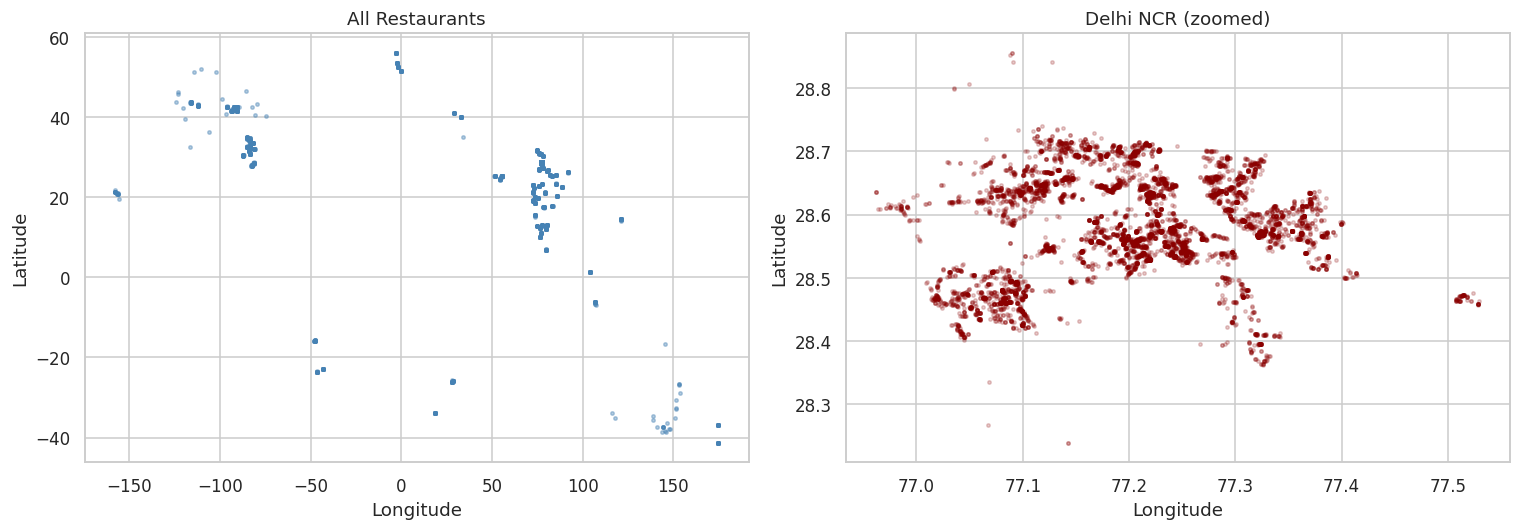

Share of mapped restaurants in Delhi NCR: 83.4 %


In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# world map
ax[0].scatter(geo["Longitude"], geo["Latitude"], s=5, alpha=0.4, color="steelblue")
ax[0].set_title("All Restaurants")
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")

# zoom on Delhi NCR (darker area = more restaurants)
ncr = geo[(geo["Latitude"] > 28.2) & (geo["Latitude"] < 29) & (geo["Longitude"] > 76.8) & (geo["Longitude"] < 77.7)]
ax[1].scatter(ncr["Longitude"], ncr["Latitude"], s=5, alpha=0.2, color="darkred")
ax[1].set_title("Delhi NCR (zoomed)")
ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("../images/07_map.png", dpi=120, bbox_inches="tight")
plt.show()

print("Share of mapped restaurants in Delhi NCR:", round(len(ncr) / len(geo) * 100, 1), "%")

**Insight:** Most restaurants (83%) are in the Delhi NCR area (Delhi, Gurgaon, Noida, Faridabad). Other countries show up as small separate groups. The busiest locality is **Connaught Place**.

## Task 4: Restaurant Chains

**Logic:** A chain is a restaurant name that appears **5 or more times** (many outlets).

In [24]:
name_count = df["Restaurant Name"].value_counts()
chains = name_count[name_count >= 5]
print("Number of chains:", len(chains))
print("Outlets in chains:", chains.sum(), "of", len(df))
chains.head(10)

Number of chains: 112
Outlets in chains: 1395 of 9551


,count
Restaurant Name,
Cafe Coffee Day,83
Domino's Pizza,79
Subway,63
Green Chick Chop,51
McDonald's,48
Keventers,34
Pizza Hut,30
Giani,29
Baskin Robbins,28


In [25]:
# rating and votes of chains (rated outlets only)
chain_rows = rated[rated["Restaurant Name"].isin(chains.index)]

chain_info = pd.DataFrame({
    "Outlets": chains,
    "Avg Rating": chain_rows.groupby("Restaurant Name")["Aggregate rating"].mean().round(2),
    "Total Votes": chain_rows.groupby("Restaurant Name")["Votes"].sum(),
})
chain_info = chain_info.dropna().sort_values("Outlets", ascending=False)

print("Top 5 chains by outlets:")
print(chain_info.head(5))
print()
print("Top 5 chains by rating:")
print(chain_info.sort_values("Avg Rating", ascending=False).head(5))
print()
print("Top 5 chains by votes (popularity):")
print(chain_info.sort_values("Total Votes", ascending=False).head(5))

Top 5 chains by outlets:
                  Outlets  Avg Rating  Total Votes
Restaurant Name                                   
Cafe Coffee Day        83        3.00       2412.0
Domino's Pizza         79        2.93       6637.0
Subway                 63        3.00       6122.0
Green Chick Chop       51        3.10        953.0
McDonald's             48        3.41       5290.0

Top 5 chains by rating:
                 Outlets  Avg Rating  Total Votes
Restaurant Name                                  
Chili's                5        4.58       8156.0
Farzi Cafe             6        4.37      10098.0
Barbeque Nation       26        4.35      28142.0
Punjab Grill           5        4.34       5424.0
Mocha                  7        4.19       3111.0

Top 5 chains by votes (popularity):
                 Outlets  Avg Rating  Total Votes
Restaurant Name                                  
Barbeque Nation       26        4.35      28142.0
Farzi Cafe             6        4.37      10098.0
Chili'

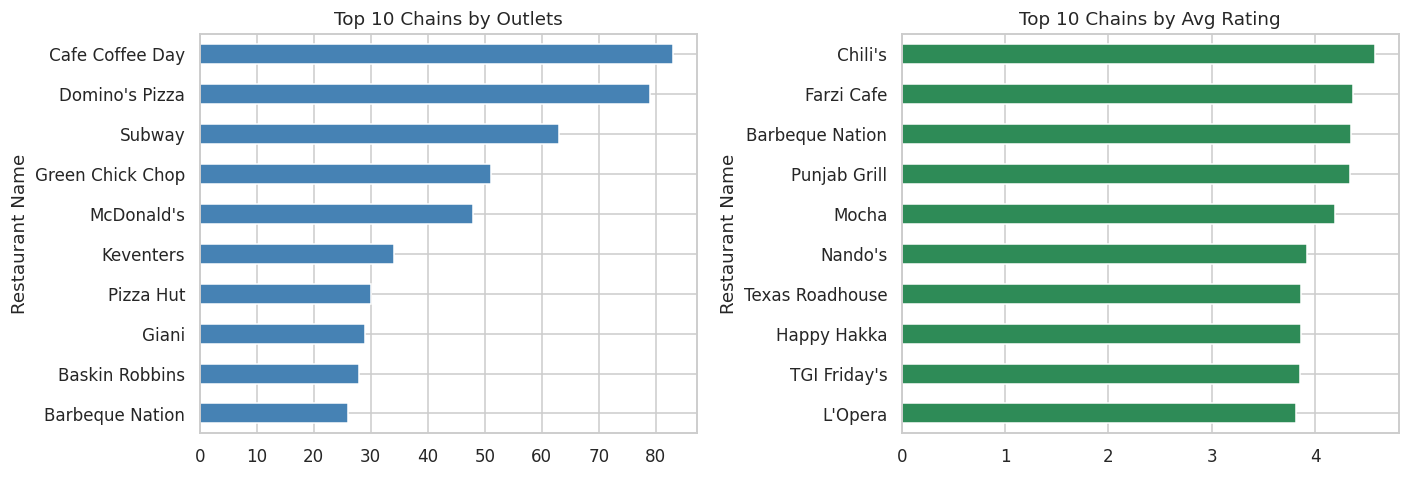

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

chain_info.head(10)["Outlets"].sort_values().plot(kind="barh", ax=ax[0], color="steelblue")
ax[0].set_title("Top 10 Chains by Outlets")

chain_info.sort_values("Avg Rating", ascending=False).head(10)["Avg Rating"].sort_values().plot(kind="barh", ax=ax[1], color="seagreen")
ax[1].set_title("Top 10 Chains by Avg Rating")

plt.tight_layout()
plt.savefig("../images/08_chains.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** Yes, chains exist. 112 names have 5+ outlets. The biggest chain is **Cafe Coffee Day** (83 outlets). But the biggest chains are not the best rated - the top rated chain is **Chili's**.

---
# Level 3 - Advanced Analysis
## Task 1: Restaurant Reviews - Not Possible

This task needs **review text** (to find positive and negative words and review length). Our dataset has **no review column**. The columns are:

In [27]:
print(list(df.columns))

['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


So this task is **skipped**. No fake data was added. If a reviews file is added later, the steps would be:
1. Make text lowercase and remove common words (like "the", "is").
2. Count words in good reviews (rating 4+) and bad reviews (rating below 2.5).
3. Find review length with `review.str.split().str.len()` and compare it with rating.

## Task 2: Votes Analysis

In [28]:
cols = ["Restaurant Name", "City", "Aggregate rating", "Votes"]

print("Top 10 restaurants by votes:")
print(df.nlargest(10, "Votes")[cols].to_string(index=False))

print()
print("Restaurants with 0 votes:", (df["Votes"] == 0).sum())
print("Lowest votes (rated restaurants):")
print(rated.nsmallest(5, "Votes")[cols].to_string(index=False))

Top 10 restaurants by votes:
          Restaurant Name      City  Aggregate rating  Votes
                     Toit Bangalore               4.8  10934
                 Truffles Bangalore               4.7   9667
         Hauz Khas Social New Delhi               4.3   7931
                Peter Cat   Kolkata               4.3   7574
AB's - Absolute Barbecues Bangalore               4.6   6907
          Barbeque Nation   Kolkata               4.9   5966
              Big Brewsky Bangalore               4.5   5705
AB's - Absolute Barbecues Hyderabad               4.9   5434
          The Black Pearl Bangalore               4.1   5385
                    BarBQ   Kolkata               4.2   5288

Restaurants with 0 votes: 1094
Lowest votes (rated restaurants):
Restaurant Name      City  Aggregate rating  Votes
   Desire Foods Faridabad               2.9      4
    Snax Points Faridabad               3.0      4
  Cafe And More Faridabad               2.9      4
 Baskin Robbins Faridabad     

In [29]:
# correlation between votes and rating (rated only)
corr = rated["Votes"].corr(rated["Aggregate rating"])
print("Correlation (votes vs rating):", round(corr, 2))

# average rating for different vote groups
groups = pd.cut(rated["Votes"], bins=[0, 50, 200, 1000, 20000],
                labels=["Below 50", "50-200", "200-1000", "Above 1000"])
group_avg = rated.groupby(groups)["Aggregate rating"].mean().round(2)
group_avg

Correlation (votes vs rating): 0.41


,Aggregate rating
Votes,
Below 50,3.13
50-200,3.51
200-1000,3.94
Above 1000,4.20


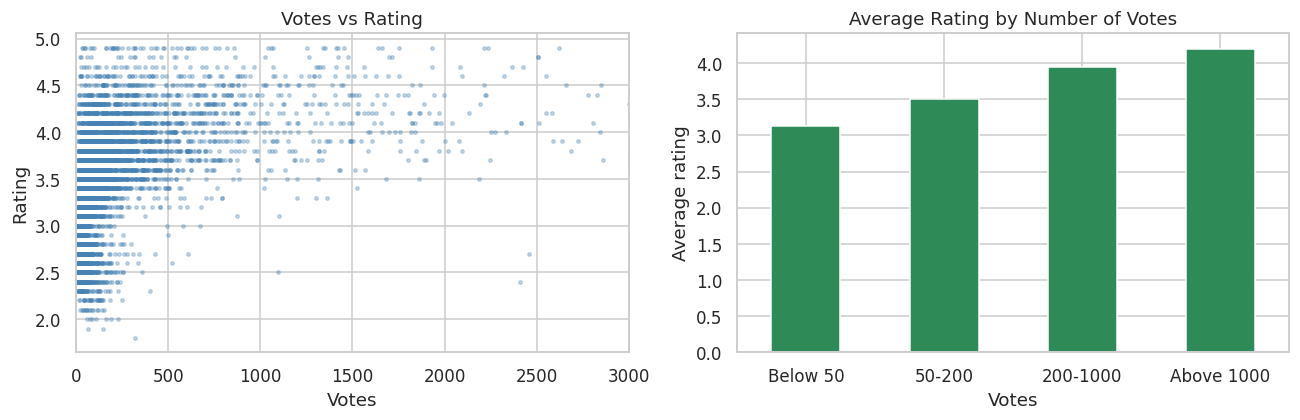

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(rated["Votes"], rated["Aggregate rating"], s=5, alpha=0.3, color="steelblue")
ax[0].set_xlim(0, 3000)
ax[0].set_title("Votes vs Rating")
ax[0].set_xlabel("Votes")
ax[0].set_ylabel("Rating")

group_avg.plot(kind="bar", ax=ax[1], color="seagreen")
ax[1].set_title("Average Rating by Number of Votes")
ax[1].set_xlabel("Votes")
ax[1].set_ylabel("Average rating")
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../images/09_votes_vs_rating.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** The correlation is **0.41** (positive). Restaurants with more votes tend to have **higher ratings**: below 50 votes the average rating is 3.13 and above 1000 votes it is 4.2. This shows a link, but it does not prove that votes cause higher ratings. All 1,094 restaurants with 0 votes are unrated.

## Task 3: Price Range vs Online Delivery and Table Booking

**Logic:** For each price range, find what % of restaurants say "Yes" for delivery and for table booking.

In [31]:
delivery = (pd.crosstab(df["Price range"], df["Has Online delivery"], normalize="index") * 100).round(2)
booking = (pd.crosstab(df["Price range"], df["Has Table booking"], normalize="index") * 100).round(2)

result = pd.DataFrame({"% Online Delivery": delivery["Yes"],
                       "% Table Booking": booking["Yes"]})
result

,% Online Delivery,% Table Booking
Price range,,
1,15.77,0.02
2,41.31,7.68
3,29.19,45.74
4,9.04,46.76


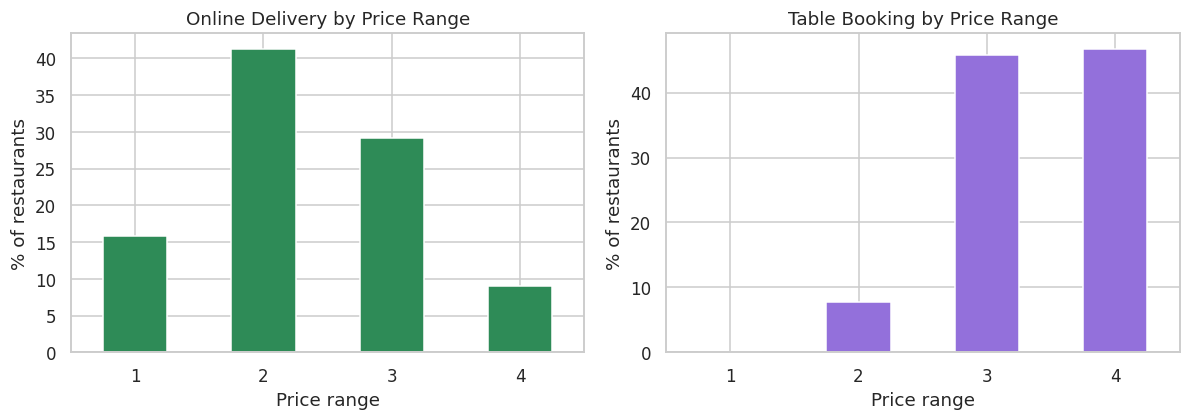

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

result["% Online Delivery"].plot(kind="bar", ax=ax[0], color="seagreen")
ax[0].set_title("Online Delivery by Price Range")
ax[0].set_ylabel("% of restaurants")

result["% Table Booking"].plot(kind="bar", ax=ax[1], color="mediumpurple")
ax[1].set_title("Table Booking by Price Range")
ax[1].set_ylabel("% of restaurants")

for a in ax:
    a.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../images/10_price_vs_services.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:**
- **Table booking:** goes up with price - from 0.02% (range 1) to 46.76% (range 4). Costly restaurants are much more likely to offer table booking.
- **Online delivery:** does not go up with price. It is highest in range 2 (41.31%) and lowest in range 4 (9.04%). Costly restaurants are **less** likely to offer delivery.

---
# Summary

| Task | Finding |
|---|---|
| Top cuisines | North Indian (41.46%), Chinese (28.64%), Fast Food (20.79%) |
| City | New Delhi has the most restaurants (5,473) |
| Price range | 79% of restaurants are in range 1 and 2 |
| Online delivery | 25.66% offer it; rating is almost the same inside India |
| Ratings | Most common range is (3.0, 3.5] |
| Chains | 112 chains with 5+ outlets |
| Votes | More votes = higher rating (correlation 0.41) |
| Price vs services | Table booking rises with price; delivery does not |
| Reviews | Not possible - no review data |